## Eda Inicial

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Shape of the dataset: (7728394, 46)

First 5 rows:
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Su

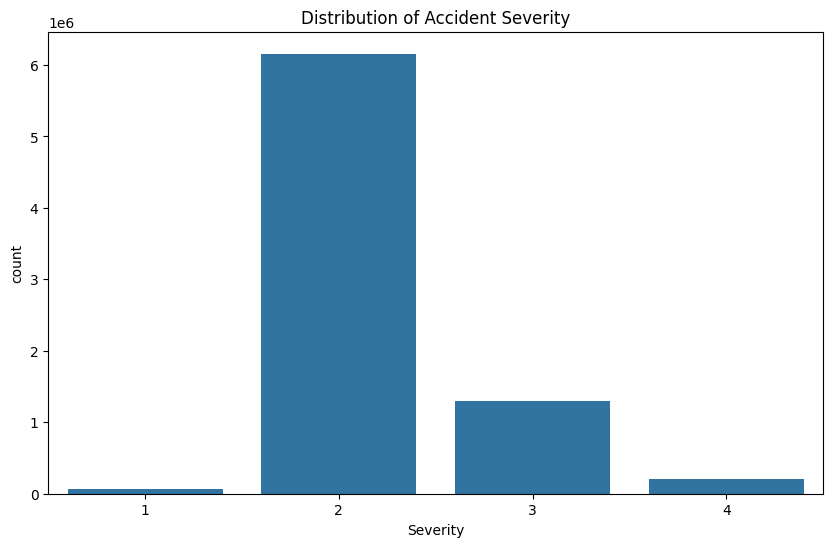

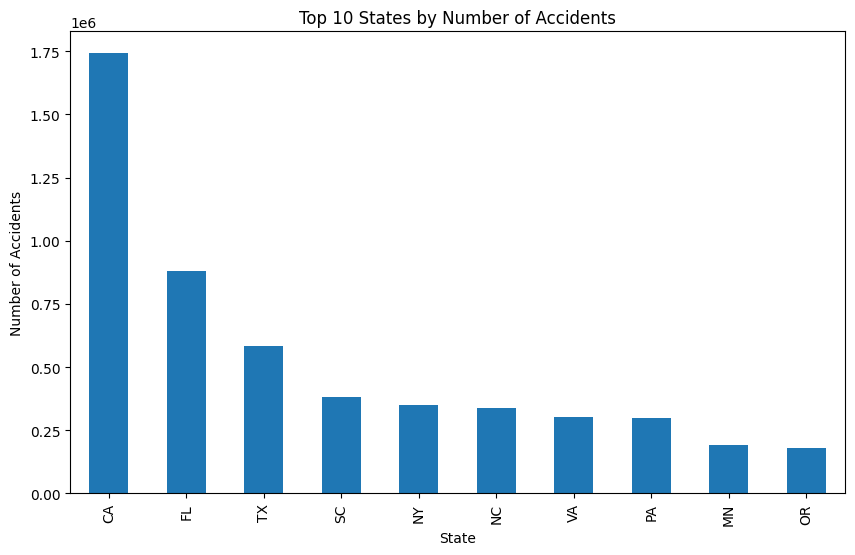

In [4]:
# Read the CSV file
df = pd.read_csv('csv/US_Accidents_March23.csv')

# Basic exploration
print("Shape of the dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types and non-null counts:")
print(df.info())
print("\nSummary statistics for numerical columns:")
print(df.describe())
print("\nMissing values per column:")
print(df.isnull().sum())

# Plot some basic visualizations
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Severity')
plt.title('Distribution of Accident Severity')
plt.show()

plt.figure(figsize=(10, 6))
df['State'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 States by Number of Accidents')
plt.xlabel('State')
plt.ylabel('Number of Accidents')
plt.show()

In [5]:
# Read the CSV file
df = pd.read_csv('csv/US_Accidents_March23.csv')

# Convert Start_Time to datetime for time-based analysis
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Extract hour, day of week, and month for deeper insights
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek
df['Month'] = df['Start_Time'].dt.month

# Correlation matrix for numerical features (printed as table)
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()
print("Correlation Matrix:")
print(corr_matrix)

# Accidents by hour of day (value counts)
print("\nAccidents by Hour of Day:")
print(df['Hour'].value_counts().sort_index())

# Accidents by day of week (value counts)
print("\nAccidents by Day of Week (0=Monday):")
print(df['DayOfWeek'].value_counts().sort_index())

# Groupby severity and calculate mean temperature
print("\nMean Temperature by Severity:")
print(df.groupby('Severity')['Temperature(F)'].mean())

# Groupby state and count accidents, top 10
print("\nTop 10 States by Accident Count:")
print(df['State'].value_counts().head(10))

# Check for outliers in numerical columns using IQR
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
    print(f"\nOutliers in {col}: {outliers}")

# Cross-tabulation of Severity and Weather_Condition (top 10 conditions)
top_conditions = df['Weather_Condition'].value_counts().head(10).index
print("\nCross-tabulation of Severity and Top 10 Weather Conditions:")
print(pd.crosstab(df['Severity'], df['Weather_Condition'][df['Weather_Condition'].isin(top_conditions)]))

Correlation Matrix:
                   Severity  Start_Lat  Start_Lng   End_Lat   End_Lng  \
Severity           1.000000   0.069060   0.052862  0.083724  0.093190   
Start_Lat          0.069060   1.000000  -0.067720  0.999993 -0.121743   
Start_Lng          0.052862  -0.067720   1.000000 -0.121735  0.999999   
End_Lat            0.083724   0.999993  -0.121735  1.000000 -0.121732   
End_Lng            0.093190  -0.121743   0.999999 -0.121732  1.000000   
Distance(mi)       0.034787   0.064064   0.007851  0.067932  0.005876   
Temperature(F)    -0.020327  -0.443781  -0.010652 -0.468692  0.024084   
Wind_Chill(F)     -0.070039  -0.480296  -0.031810 -0.489578  0.006733   
Humidity(%)        0.022293   0.022364   0.179500  0.027849  0.167428   
Pressure(in)       0.042347  -0.194094   0.193185 -0.242143  0.216028   
Visibility(mi)    -0.003473  -0.088500  -0.015322 -0.116199  0.006155   
Wind_Speed(mph)    0.040214   0.032908   0.077353  0.017373  0.092303   
Precipitation(in)  0.021080   0

In [6]:
def load_data(path: str) -> pd.DataFrame:
    """
    Carga el dataset desde CSV.
    """
    df = pd.read_csv(path, low_memory=False)
    print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
    return df


In [7]:
def dataset_overview(df: pd.DataFrame) -> None:
    """
    Muestra dimensiones, columnas y tipos de datos.
    """
    display(df.head())
    print("\nShape:", df.shape)
    print("\nTipos de datos:")
    display(df.dtypes)


In [8]:
dataset_overview(df)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Hour,DayOfWeek,Month
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,Night,Night,Night,Night,5.0,0.0,2.0
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,Night,Night,Night,Day,6.0,0.0,2.0
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,True,False,Night,Night,Day,Day,6.0,0.0,2.0
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,Night,Day,Day,Day,7.0,0.0,2.0
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,True,False,Day,Day,Day,Day,7.0,0.0,2.0



Shape: (7728394, 49)

Tipos de datos:


ID                               object
Source                           object
Severity                          int64
Start_Time               datetime64[ns]
End_Time                         object
Start_Lat                       float64
Start_Lng                       float64
End_Lat                         float64
End_Lng                         float64
Distance(mi)                    float64
Description                      object
Street                           object
City                             object
County                           object
State                            object
Zipcode                          object
Country                          object
Timezone                         object
Airport_Code                     object
Weather_Timestamp                object
Temperature(F)                  float64
Wind_Chill(F)                   float64
Humidity(%)                     float64
Pressure(in)                    float64
Visibility(mi)                  float64


In [9]:
def convert_datetime_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """
    Convierte columnas a datetime.
    """
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors='coerce')
            print(f"Columna convertida a datetime: {c}")
    return df


In [10]:
datetime_cols = ['Start_Time', 'End_Time', 'Weather_Timestamp']
df = convert_datetime_columns(df, datetime_cols)


Columna convertida a datetime: Start_Time
Columna convertida a datetime: End_Time
Columna convertida a datetime: Weather_Timestamp


In [11]:
def null_analysis(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    """
    Retorna porcentaje de valores nulos por columna.
    """
    nulls = (
        df.isnull()
          .sum()
          .to_frame(name='null_count')
          .assign(null_pct=lambda x: x['null_count'] / len(df) * 100)
          .sort_values('null_pct', ascending=False)
    )
    display(nulls.head(top_n))
    return nulls


In [12]:
nulls_df = null_analysis(df)


,null_count,null_pct
End_Lat,3402762,44.029355
End_Lng,3402762,44.029355
Precipitation(in),2203586,28.512858
Wind_Chill(F),1999019,25.865904
End_Time,743166,9.616047
Month,743166,9.616047
Hour,743166,9.616047
Start_Time,743166,9.616047
DayOfWeek,743166,9.616047
Wind_Speed(mph),571233,7.391355


In [13]:
def descriptive_statistics(df: pd.DataFrame) -> None:
    """
    Estadísticos básicos de variables numéricas.
    """
    display(df.describe())


In [14]:
descriptive_statistics(df)


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Hour,DayOfWeek,Month
count,7.728394e+06,6985228,6985228,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7608166,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06,6.985228e+06,6.985228e+06,6.985228e+06
mean,2.212384e+00,2020-03-21 21:49:59.056443136,2020-03-22 04:56:51.646936064,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,2020-06-02 10:06:41.888674560,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03,1.226779e+01,2.568768e+00,6.747753e+00
min,1.000000e+00,2016-01-14 20:18:33,2016-02-08 06:37:08,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,2016-01-14 19:51:00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,2.000000e+00,2018-09-17 02:20:31.750000128,2018-09-17 05:23:37.500000,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,2018-11-20 18:35:00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00,8.000000e+00,1.000000e+00,4.000000e+00
50%,2.000000e+00,2020-06-23 13:37:23.500000,2020-06-23 15:20:42,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,2020-11-10 13:53:00,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00,1.300000e+01,3.000000e+00,7.000000e+00
75%,2.000000e+00,2021-10-28 15:44:07,2021-10-29 14:57:46.500000,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,2022-01-19 14:27:00,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00,1.700000e+01,4.000000e+00,1.000000e+01
max,4.000000e+00,2023-03-31 23:30:00,2023-03-31 23:59:00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2023-03-31 23:53:00,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01,2.300000e+01,6.000000e+00,1.200000e+01
std,4.875313e-01,NaN,NaN,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,NaN,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01,5.455518e+00,1.796839e+00,3.623057e+00


In [15]:
def duplicate_analysis(df: pd.DataFrame, key: str = 'ID') -> int:
    """
    Analiza duplicados por clave primaria.
    """
    if key not in df.columns:
        print("Clave no encontrada.")
        return 0

    dup_count = df[key].duplicated().sum()
    print(f"Registros duplicados por {key}: {dup_count}")
    return dup_count


In [17]:
duplicate_analysis(df)


Registros duplicados por ID: 0


np.int64(0)

In [16]:
def severity_distribution(df: pd.DataFrame) -> pd.Series:
    """
    Distribución de severidad.
    """
    severity = df['Severity'].value_counts().sort_index()
    display(severity)
    return severity


In [18]:
severity_distribution(df)


Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64

Severity
1      67366
2    6156981
3    1299337
4     204710
Name: count, dtype: int64

In [19]:
def hourly_distribution(df: pd.DataFrame) -> pd.Series:
    """
    Distribución de accidentes por hora.
    """
    df['hour'] = df['Start_Time'].dt.hour
    hours = df['hour'].value_counts().sort_index()
    display(hours)
    return hours


In [20]:
hourly_distribution(df)


hour
0.0      98452
1.0      85743
2.0      82394
3.0      74229
4.0     149077
5.0     209579
6.0     375179
7.0     546789
8.0     541643
9.0     334067
10.0    313625
11.0    322215
12.0    316904
13.0    352361
14.0    394697
15.0    463389
16.0    520177
17.0    516626
18.0    390621
19.0    267045
20.0    201883
21.0    169500
22.0    148605
23.0    110428
Name: count, dtype: int64

hour
0.0      98452
1.0      85743
2.0      82394
3.0      74229
4.0     149077
5.0     209579
6.0     375179
7.0     546789
8.0     541643
9.0     334067
10.0    313625
11.0    322215
12.0    316904
13.0    352361
14.0    394697
15.0    463389
16.0    520177
17.0    516626
18.0    390621
19.0    267045
20.0    201883
21.0    169500
22.0    148605
23.0    110428
Name: count, dtype: int64

In [21]:
def top_locations(df: pd.DataFrame, col: str, top_n: int = 10) -> pd.Series:
    """
    Top N ubicaciones con más accidentes.
    """
    top = df[col].value_counts().head(top_n)
    display(top)
    return top


In [22]:
top_locations(df, 'State')
top_locations(df, 'City')


State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
Name: count, dtype: int64

City
Miami          186917
Houston        169609
Los Angeles    156491
Charlotte      138652
Dallas         130939
Orlando        109733
Austin          97359
Raleigh         86079
Nashville       72930
Baton Rouge     71588
Name: count, dtype: int64

City
Miami          186917
Houston        169609
Los Angeles    156491
Charlotte      138652
Dallas         130939
Orlando        109733
Austin          97359
Raleigh         86079
Nashville       72930
Baton Rouge     71588
Name: count, dtype: int64

In [23]:
def create_sample_dataset(
    df: pd.DataFrame,
    n_rows: int = 1000,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Genera un subconjunto del dataset con al menos n_rows filas.
    """
    if len(df) <= n_rows:
        print("El dataset ya es menor o igual al tamaño solicitado.")
        return df.copy()

    sample_df = df.sample(n=n_rows, random_state=random_state)
    print(f"Sample generado: {sample_df.shape[0]} filas")
    return sample_df


In [26]:
df_sample = create_sample_dataset(df, n_rows=1000)


Sample generado: 1000 filas


In [24]:
def save_sample_csv(
    df_sample: pd.DataFrame,
    output_path: str = 'csv/US_Accidents_sample_1k.csv'
) -> None:
    """
    Guarda el sample en CSV.
    """
    df_sample.to_csv(output_path, index=False)
    print(f"Archivo generado: {output_path}")


In [27]:
save_sample_csv(df_sample)


Archivo generado: csv/US_Accidents_sample_1k.csv
